In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlalchemy
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

load_dotenv()

DB_HOST = os.getenv("SUPABASE_HOST")
DB_DB = os.getenv("SUPABASE_DB")
DB_USER = os.getenv("SUPABASE_USER")
DB_PASSWORD = quote_plus(os.getenv("SUPABASE_PASSWORD"))
DB_PORT = os.getenv("SUPABASE_PORT")

engine = sqlalchemy.create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_DB}",
    connect_args={"sslmode": "require"},
    pool_pre_ping=True
)

print("✅ Connected to database")

✅ Connected to database


In [2]:
df = pd.read_sql('SELECT * FROM river_levels ORDER BY reading_time ASC', engine)
print(f"Total records: {len(df)}")
print(f"Date range: {df['reading_time'].min()} to {df['reading_time'].max()}")
print(f"Stations: {df['station'].unique()}")

Total records: 13539
Date range: 2025-06-20 16:00:00 to 2026-06-21 13:00:00
Stations: <ArrowStringArray>
['Hathnikund Barrage', 'Kalanaur', 'Fatehgarh']
Length: 3, dtype: str


In [3]:

station_df = df[df['station'] == 'Hathnikund Barrage'].sort_values('reading_time').copy()
station_df = station_df[['reading_time', 'water_level']].dropna()
station_df = station_df.drop_duplicates(subset='reading_time')

print(f"Hathnikund records: {len(station_df)}")
print(station_df.head())

Hathnikund records: 4143
          reading_time  water_level
0  2025-06-20 16:00:00       333.56
5  2025-06-20 17:00:00       333.60
7  2025-06-20 18:00:00       333.58
11 2025-06-20 19:00:00       333.56
12 2025-06-20 20:00:00       333.52


In [4]:
from sklearn.preprocessing import MinMaxScaler

# Scale water levels between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(station_df[['water_level']])

# Create sequences: 24 hours in, 1 hour prediction out
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])  # last 24 readings
        y.append(data[i, 0])              # next reading
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, lookback=24)

print(f"X shape: {X.shape}  meaning {X.shape[0]} examples, each with {X.shape[1]} hourly readings")
print(f"y shape: {y.shape}  meaning {y.shape[0]} answers to predict")

X shape: (4119, 24)  meaning 4119 examples, each with 24 hourly readings
y shape: (4119,)  meaning 4119 answers to predict


In [5]:
# Split into train and test - same concept as flowers and houses
split = int(len(X) * 0.9)  # 90% train, 10% test

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM: needs [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Training examples: {X_train.shape[0]}")
print(f"Testing examples: {X_test.shape[0]}")

Training examples: 3707
Testing examples: 412


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(24, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 24, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

print("✅ Training complete")

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0194 - val_loss: 0.0075
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0042 - val_loss: 0.0069
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0034 - val_loss: 0.0073
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0033 - val_loss: 0.0071
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0029 - val_loss: 0.0056
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0027 - val_loss: 0.0046
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0023 - val_loss: 0.0036
Epoch 9/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0021 - val_loss: 0.0032
Epoch 10/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0020 - val_loss: 0.0040
Epoch 11/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0017 - val_loss: 0.0039
Epoch 12/20
105/105 ━━━━━━━━━━━━━━━━━━━━

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


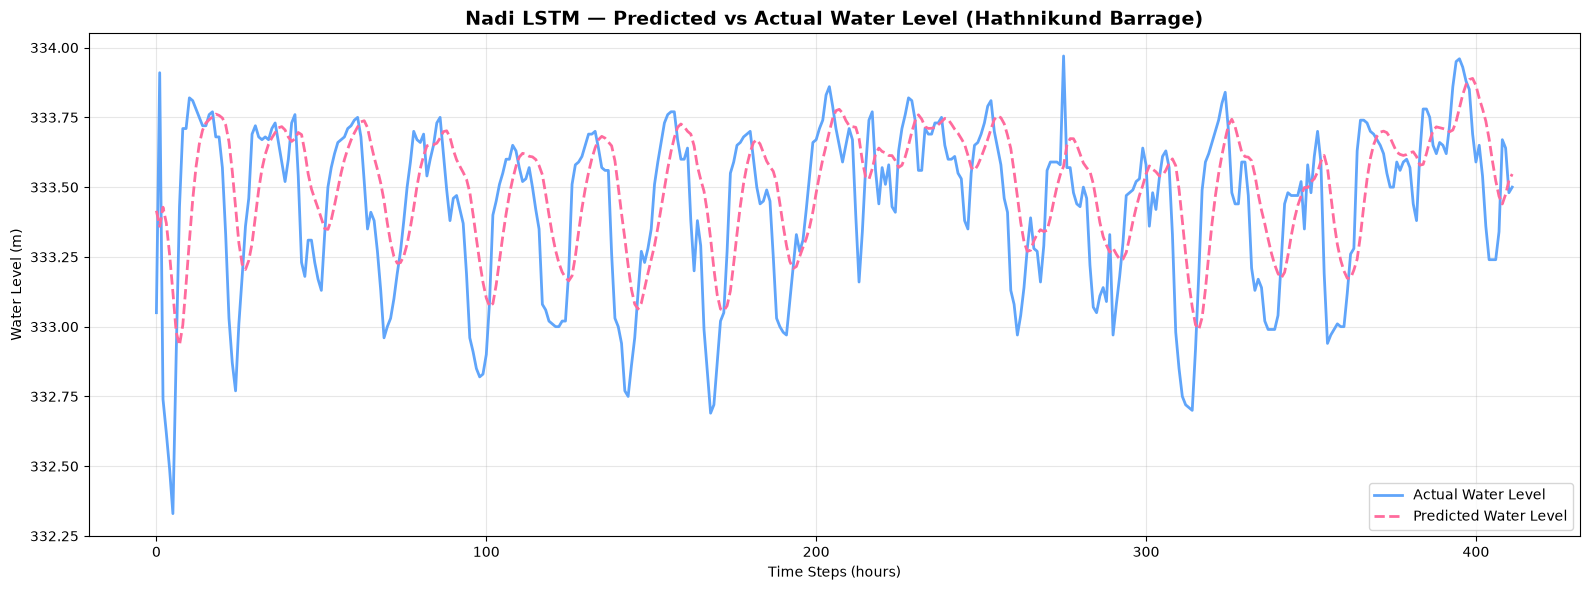


Mean Absolute Error: 0.2010 meters
On average the model is off by 20.10 cm


In [9]:
predictions = model.predict(X_test)

# Convert back to real water level values (undo the scaling)
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test_actual, label='Actual Water Level', color='#60a5fa', linewidth=2)
ax.plot(predictions_actual, label='Predicted Water Level', color='#ff6b9d', linewidth=2, linestyle='--')
ax.set_title('Nadi LSTM — Predicted vs Actual Water Level (Hathnikund Barrage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Steps (hours)')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate MAE (same metric we used for house prices)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test_actual, predictions_actual)
print(f"\nMean Absolute Error: {mae:.4f} meters")
print(f"On average the model is off by {mae*100:.2f} cm")

In [10]:
import os
os.makedirs("models", exist_ok=True)
model.save("models/nadi_lstm.keras")
scaler_params = {
    'min': scaler.data_min_[0],
    'max': scaler.data_max_[0]
}
import json
with open("models/scaler_params.json", "w") as f:
    json.dump(scaler_params, f)

print("✅ Model saved to models/nadi_lstm.keras")
print("✅ Scaler saved to models/scaler_params.json")

✅ Model saved to models/nadi_lstm.keras
✅ Scaler saved to models/scaler_params.json
